<a href="https://colab.research.google.com/github/hridayyhere/DOG-vs-CAT-prediction/blob/main/DOG_VS_CAT_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/


In [10]:
!kaggle competitions download -c dogs-vs-cats

403 Client Error: Forbidden for url: https://www.kaggle.com/api/v1/competitions/data/download-all/dogs-vs-cats


In [11]:
!kaggle datasets download -d salader/dogs-vs-cats

Dataset URL: https://www.kaggle.com/datasets/salader/dogs-vs-cats
License(s): unknown


In [12]:
import zipfile
zipfile.ZipFile('dogs-vs-cats.zip').extractall('.')
zipfile.ZipFile('dogs-vs-cats.zip').close()

In [13]:
zipfile.ZipFile('dogs-vs-cats.zip').extractall('.')

In [14]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

In [15]:
train_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)
validation_ds = keras.utils.image_dataset_from_directory(
    directory='/content/train',
    labels='inferred',
    label_mode='int',
    batch_size=32,
    image_size=(256, 256)
)

Found 20000 files belonging to 2 classes.
Found 20000 files belonging to 2 classes.


In [16]:
#normalise
def process(image, label):
  image = tf.cast(image/255. , tf.float32)
  return image, label

train_ds = train_ds.map(process)
validation_ds = validation_ds.map(process)

In [17]:
#create cnn model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(256, 256, 3)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Conv2D(64, kernel_size=(3, 3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 246016)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    31,490,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,509,697 (120.20 MB)

 Trainable params: 31,509,697 (120.20 MB)

 Non-trainable params: 0 (0.00 B)

In [19]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
 history = model.fit(train_ds, epochs=10, validation_data=validation_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.9953 - loss: 0.0190 - val_accuracy: 0.9627 - val_loss: 0.1108
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 66s 89ms/step - accuracy: 0.9953 - loss: 0.0154 - val_accuracy: 0.9845 - val_loss: 0.0509
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 89ms/step - accuracy: 0.9954 - loss: 0.0155 - val_accuracy: 0.9920 - val_loss: 0.0278
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 89ms/step - accuracy: 0.9979 - loss: 0.0097 - val_accuracy: 0.9876 - val_loss: 0.0393
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.9975 - loss: 0.0083 - val_accuracy: 0.9919 - val_loss: 0.0247
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 82s 116ms/step - accuracy: 0.9966 - loss: 0.0107 - val_accuracy: 0.9912 - val_loss: 0.0294
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 71s 98ms/step - accuracy: 0.9952 - loss: 0.0158 - val_accuracy: 0.9935 - val_loss: 0.0219
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 56s 90ms/step - accuracy: 0.9976 - loss: 0.0112

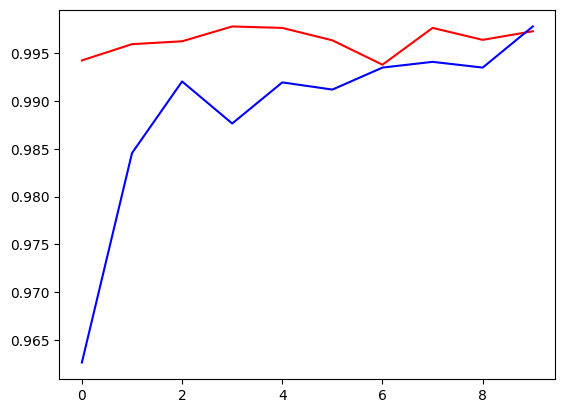

In [25]:
import matplotlib.pyplot as plt
plt.plot(history.history['accuracy'],color ='red')
plt.plot(history.history['val_accuracy'],color ='blue')


In [28]:
import cv2
import numpy as np

In [30]:
image_path='/pexels-photo-220938.jpeg'
img=cv2.imread(image_path)
img=cv2.resize(img,(256,256))
img=img/255.0
img=np.expand_dims(img,axis=0)

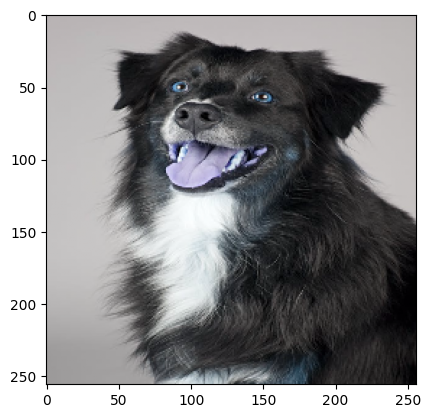

In [31]:
plt.imshow(img[0])

In [32]:
model.predict(img)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 976ms/step


array([[1.]], dtype=float32)

*HENCE MODEL IS ACCURATEt**